In [60]:
import pandas as pd
import numpy as np
import scipy.stats as st
from numpy.linalg import lstsq, solve
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
#read in the exoplanet data
df = pd.read_csv('exoplanets.csv', comment='#', low_memory=False)
df = df[['pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_masse', 'pl_masseerr1', 'pl_masseerr2', 'st_mass']]

In [3]:
ss_planets = pd.read_csv('Solar_system.csv', usecols=[0, 2, 3], skiprows=2,
                         names=['name', 'radius', 'mass'])

In [4]:
ss_planets['mass_err'] = ss_planets.apply(lambda x: float(x['mass'].split('±')[-1]), axis=1)
ss_planets['radius_err'] = ss_planets.apply(lambda x: float(x['radius'].split('±')[-1]), axis=1)
ss_planets['mass'] = ss_planets.apply(lambda x: float(x['mass'].split()[0]), axis=1)
ss_planets['radius'] = ss_planets.apply(lambda x: float(x['radius'].split()[0]), axis=1)

In [5]:
ss_planets['mass_err'] = ss_planets['mass_err']/ss_planets.loc[2]['mass']
ss_planets['mass'] = ss_planets['mass']/ss_planets.loc[2]['mass']
ss_planets['radius_err'] = ss_planets['radius_err']/ss_planets.loc[2]['radius']
ss_planets['radius'] = ss_planets['radius']/ss_planets.loc[2]['radius']

In [6]:
#drop NaNs
sample_a = df.dropna()
print(sample_a.shape) #new sample size


(2892, 7)


In [7]:
def log_errs(val, errs, err_lower=None):
    err_lower = errs if err_lower is None else np.abs(err_lower)
    upper = np.log10(val+errs)
    mask = (val - errs <= 0)
    lower = np.log10(val-err_lower)
    lower[mask] = -np.inf
    logerr = 0.5*(upper-lower)
    return logerr

In [66]:
logMa = np.log10(sample_a['pl_masse']).values
logRa = np.log10(sample_a['pl_rade']).values
sigma_r = log_errs(sample_a['pl_rade'].values, sample_a['pl_radeerr1'].values, sample_a['pl_radeerr2'].values)
sigma_m = log_errs(sample_a['pl_masse'].values, sample_a['pl_masseerr1'].values, sample_a['pl_masseerr2'].values)

rmask = ~np.isinf(sigma_r)
mmask = ~(np.isinf(sigma_m) | np.isnan(sigma_m))
mask = rmask & mmask


C:\Users\danic\AppData\Local\Temp\ipykernel_40220\2343081272.py:5: RuntimeWarning: invalid value encountered in log10
  lower = np.log10(val-err_lower)
C:\Users\danic\AppData\Local\Temp\ipykernel_40220\2343081272.py:5: RuntimeWarning: divide by zero encountered in log10
  lower = np.log10(val-err_lower)


In [67]:
def rbf_kernel(a, b, l, sig_f):
    sqdist = np.sum(a**2,1).reshape(-1,1) + np.sum(b**2,1)- 2*np.dot(a, b.T)
    return sig_f**2*np.exp(-0.5/l**2*sqdist)


In [85]:

logRa_m= logRa[mask]
logMa_m = logMa[mask]
yerr = sigma_m[mask].reshape(-1,1)
sigma_n_ = yerr**2


idx = np.arange(len(logRa_m))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

X = logRa[idx_train].reshape(-1, 1)
y = logMa[idx_train]
sigma_n = sigma_n_[idx_train]

Xtest = logRa_m[idx_test].reshape(-1, 1)
sigma_n_test  = sigma_n_[idx_test]


l = 0.5
sig_f = 2
N = len(X)
n= len(Xtest)

In [86]:
# points we're going to make predictions at.
K = rbf_kernel(X, X, l, sig_f)  
L = np.linalg.cholesky(K + sigma_n.flatten()*np.eye(N))
# mean at our test points.
Lk = np.linalg.solve(L, rbf_kernel(X, Xtest, l, sig_f)) 
mu = np.dot(Lk.T, np.linalg.solve(L, y)) 

# variance at our test points. 
K_ = rbf_kernel(Xtest, Xtest, l, sig_f) 
s2 = np.diag(K_) - np.sum(Lk**2, axis=0) 
s = np.sqrt(s2) 

#draw samples from the prior distribution 
L = np.linalg.cholesky(K_ + 1e-6*np.eye(n)) 
f_prior = np.dot(L, np.random.normal(size=(n,5)))

#draw samples from the posterior distribution 
L = np.linalg.cholesky(K_ + 1e-6*np.eye(n)- np.dot(Lk.T, Lk)) 
f_post = mu.reshape(-1,1) + np.dot(L, np.random.normal(size=(n,5)))



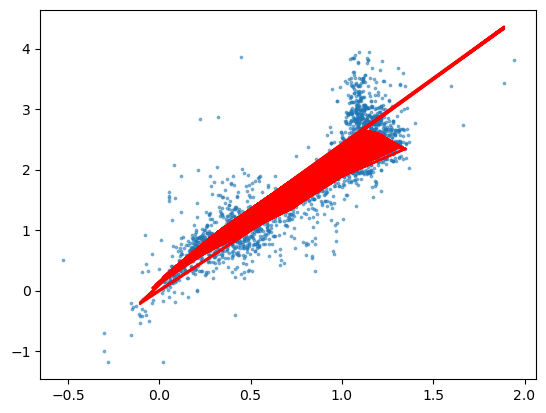

In [89]:
plt.scatter(X, y, alpha=0.5, s=3)
plt.plot(Xtest, f_post, 'r-', label='posterior')

In [48]:

def comb_rbf (a, b, p):
    k = np.zeros((len(a), len(b)))
    for l,s in p:
        k += rbf_kernel(a,b,l,s)
    return k


In [49]:
p = [(0.1,0.1),(1,1),(10,10)]

k_comb = comb_rbf(X, X, p)
L_c = np.linalg.cholesky(k_comb + sigma_n.flatten()*np.eye(N))

k_comb_c = comb_rbf(X, Xtest, p)
Lk_c = np.linalg.solve(L_c, k_comb_c) 
mu_c = np.dot(Lk_c.T, np.linalg.solve(L_c, y))

k_comb_t = comb_rbf(Xtest, Xtest, p)
s2_c = np.diag(k_comb_t) - np.sum(Lk_c**2, axis=0) 
s_c = np.sqrt(s2_c) 

#draw samples from the prior distribution 
L_c = np.linalg.cholesky(k_comb_t + 1e-6*np.eye(n)) 
f_prior_c= np.dot(L_c, np.random.normal(size=(n,5)))

#draw samples from the posterior distribution 
L_c = np.linalg.cholesky(k_comb_t + 1e-6*np.eye(n)- np.dot(Lk_c.T, Lk_c)) 
f_post_c = mu_c.reshape(-1,1) + np.dot(L_c, np.random.normal(size=(n,5)))



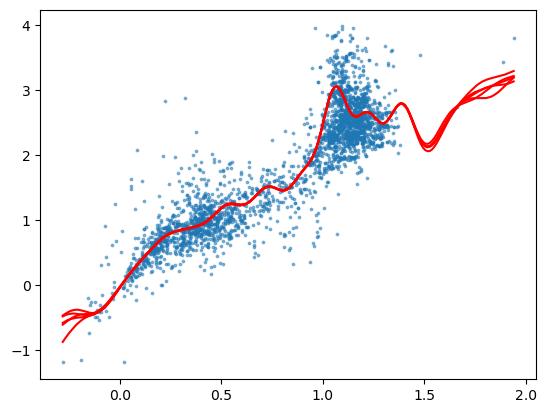

In [50]:
plt.scatter(X, y, alpha=0.5, s=3)
plt.plot(Xtest, f_post_c, 'r-', label='posterior')

In [90]:
planet_names  = ['Mercury','Venus','Earth','Mars','Jupiter','Saturn','Uranus','Neptune']
ss_logR = np.log10(ss_planets['radius'].values)
ss_logM = np.log10(ss_planets['mass'].values)
X_ss = ss_logR.reshape(-1, 1)

k_comb = comb_rbf(X, X, p)

L_c = np.linalg.cholesky(k_comb + sigma_n.flatten()*np.eye(N))

k_comb_c = comb_rbf(X, X_ss, p)
Lk_c = np.linalg.solve(L_c, k_comb_c) 
mu_c = np.dot(Lk_c.T, np.linalg.solve(L_c, y)).flatten()


K = rbf_kernel(X, X, l, sig_f)  
L = np.linalg.cholesky(K + sigma_n.flatten()*np.eye(N))

Lk = np.linalg.solve(L, rbf_kernel(X, X_ss, l, sig_f)) 
mu = np.dot(Lk.T, np.linalg.solve(L, y)).flatten() 

print("Solar System Predictions ")
print(f"{'Planet':<10} {'True':>8}  {'Combined':>10} {'Single':>10}")
for i, name in enumerate(planet_names):
    pred_m = 10**mu_c[i]
    pred_m_sing = 10**mu[i]
    print(f"{name:<10} {ss_planets['mass'][i]:>8.3f} {pred_m:>10.3f} {pred_m_sing:>10.3f}")

Solar System Predictions 
Planet         True    Combined     Single
Mercury       0.055      0.693      0.169
Venus         0.815      0.929      1.219
Earth         1.000      1.027      1.428
Mars          0.107      0.099      0.140
Jupiter     317.828    321.937    297.377
Saturn       95.161    110.233    152.536
Uranus       14.536     17.761     18.037
Neptune      17.148     15.838     17.931
